In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
from sktime.forecasting.naive import NaiveForecaster
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from scipy.special import inv_boxcox
from scipy.stats import boxcox
import pmdarima as pm




from sktime.performance_metrics.forecasting import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

In [2]:
df = pd.read_csv("mexico_weather.csv")
df = df.loc[:9000,:]

In [3]:
df["DateTime"] = pd.to_datetime(df["DateTime"])

In [4]:
df["Temperature(F)"] = pd.to_numeric(df["Temperature(F)"])

In [5]:
df.describe()

,DateTime,Lat_num,Long_num,Elevation,Temperature(F),Dew Point(F),Humidity(%),Wind Speed(mph),Wind Gust(mph),Pressure(in)
count,9001,9.001000e+03,9.001000e+03,9001.0,9001.000000,9001.000000,9001.000000,9001.000000,9001.000000,9001.000000
mean,2017-07-07 12:00:00,2.051670e+01,-1.033167e+02,1528.0,67.406464,44.747084,52.059595,3.856664,0.470244,24.890892
min,2017-01-01 00:00:00,2.051670e+01,-1.033167e+02,1528.0,34.000000,-13.000000,2.000000,0.000000,0.000000,24.680000
25%,2017-04-04 18:00:00,2.051670e+01,-1.033167e+02,1528.0,61.000000,36.000000,30.000000,0.000000,0.000000,24.850000
50%,2017-07-07 12:00:00,2.051670e+01,-1.033167e+02,1528.0,68.000000,45.000000,53.000000,3.000000,0.000000,24.890000
75%,2017-10-09 06:00:00,2.051670e+01,-1.033167e+02,1528.0,75.000000,57.000000,73.000000,6.000000,0.000000,24.930000
max,2018-01-11 00:00:00,2.051670e+01,-1.033167e+02,1528.0,97.000000,77.000000,100.000000,35.000000,52.000000,25.175000
std,NaN,7.105822e-15,2.842329e-14,0.0,11.523244,13.136794,25.489400,4.314125,3.301969,0.066782


In [49]:
display(df.head())

,DateTime,Station,Code,Country,State,City,Lat_num,Long_num,Elevation,Temperature(F),Dew Point(F),Humidity(%),Wind Speed(mph),Wind Gust(mph),Pressure(in),Wind,Condition
0,2017-01-01 00:00:00,MMGL,GDL,Mexico,Jalisco,Guadalajara,20.5167,-103.3167,1528.0,54.0,46.0,77.0,2.0,0.0,24.92,SSE,Fair
1,2017-01-01 01:00:00,MMGL,GDL,Mexico,Jalisco,Guadalajara,20.5167,-103.3167,1528.0,54.0,48.0,82.0,0.0,0.0,24.92,CALM,Fair
2,2017-01-01 02:00:00,MMGL,GDL,Mexico,Jalisco,Guadalajara,20.5167,-103.3167,1528.0,52.0,46.0,82.0,3.0,0.0,24.89,S,Fair
3,2017-01-01 03:00:00,MMGL,GDL,Mexico,Jalisco,Guadalajara,20.5167,-103.3167,1528.0,50.0,46.0,87.0,0.0,0.0,24.89,CALM,Fair
4,2017-01-01 04:00:00,MMGL,GDL,Mexico,Jalisco,Guadalajara,20.5167,-103.3167,1528.0,48.0,45.0,87.0,2.0,0.0,24.89,ESE,Fair


In [50]:
train = df["Temperature(F)"][:-int(0.2*len(df))]
test = df["Temperature(F)"][-int(0.2*len(df)):]
train_df = df[:-int(0.2*len(df))]
test_df = df[-int(0.2*len(df)):]
time_stamps = int(0.2*len(df))+1

In [51]:
baseline_model = NaiveForecaster(strategy="mean")
baseline_model.fit(train)
y_pred = baseline_model.predict(fh=[i for i in range(1,time_stamps)])

In [52]:
prediction = pd.DataFrame({"Temperature(F)":y_pred})
prediction["DateTime"] = test_df["DateTime"]

<Axes: xlabel='DateTime', ylabel='Temperature(F)'>

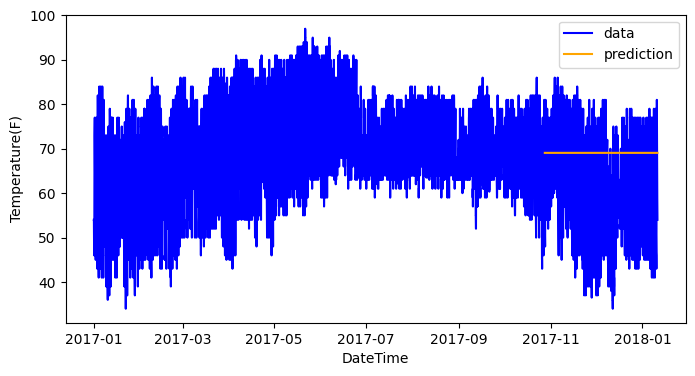

In [53]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df,x="DateTime",y="Temperature(F)",color="blue",label="data")
sns.lineplot(data=prediction,x="DateTime",y="Temperature(F)",color="orange",label="prediction")

In [54]:
mae = mean_absolute_error(test, y_pred)
rmse = mean_squared_error(test, y_pred, square_root=True)
mape = mean_absolute_percentage_error(test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 12.178665231680789
RMSE: 14.49231338605823
MAPE: 0.23299127180405566


# Using a more sophisticated model (ARIMA) and computing the performence metrics

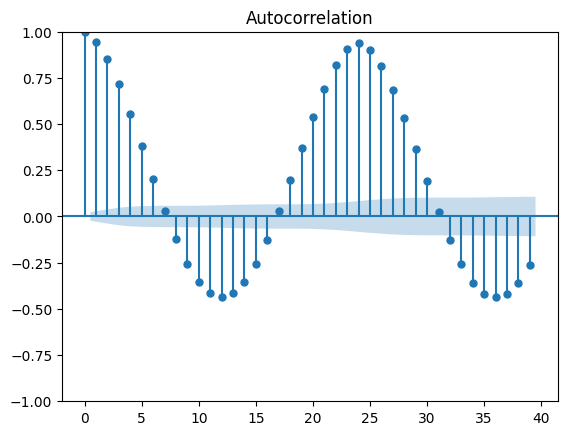

In [58]:
plot_acf(train)
plt.show()

In [59]:
model_arima = ARIMA(train,order=(20,0,20))
model_arima = model_arima.fit()
y_pred = model_arima.forecast(len(test))

/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [60]:
prediction = pd.DataFrame({"Temperature(F)":y_pred})
prediction["DateTime"] = test_df["DateTime"]

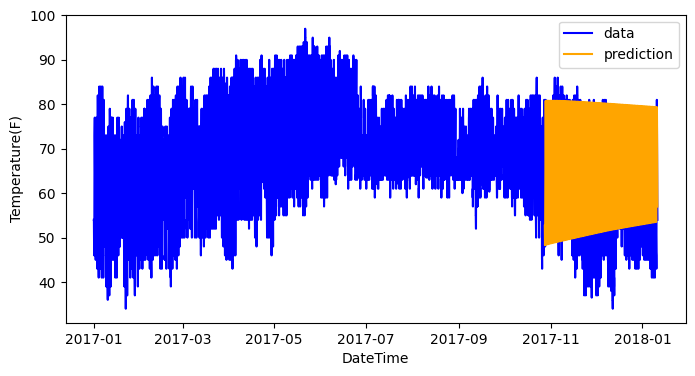

In [62]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df,x="DateTime",y="Temperature(F)",color="blue",label="data")
sns.lineplot(data=prediction,x="DateTime",y="Temperature(F)",color="orange",label="prediction")
plt.show()

In [63]:
mae = mean_absolute_error(test, y_pred)
rmse = mean_squared_error(test, y_pred, square_root=True)
mape = mean_absolute_percentage_error(test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 5.517701799365757
RMSE: 7.034041266514283
MAPE: 0.10357458927106232


# Testing a different refinement method each time and looking at the performence

* The Box Cox

In [64]:
train_BoxCox, lam = boxcox(train)
model_arima = ARIMA(train_BoxCox,order=(20,0,20))
model_arima = model_arima.fit()
y_pred = model_arima.forecast(len(test))
y_pred = inv_boxcox(y_pred,lam)

/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [65]:
test

7201    52.0
7202    52.0
7203    51.0
7204    50.0
7205    48.0
        ... 
8996    63.0
8997    59.0
8998    57.0
8999    55.0
9000    54.0
Name: Temperature(F), Length: 1800, dtype: float64

In [67]:
prediction = pd.DataFrame({"Temperature(F)":y_pred})
prediction.index = range(7201,7201+len(prediction))
prediction["DateTime"] = test_df["DateTime"]

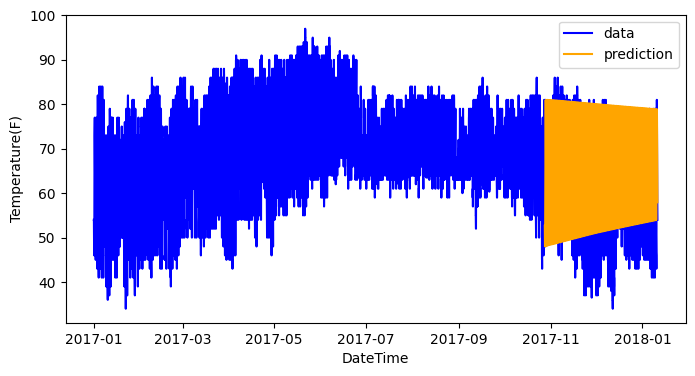

In [69]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df,x="DateTime",y="Temperature(F)",color="blue",label="data")
sns.lineplot(data=prediction,x="DateTime",y="Temperature(F)",color="orange",label="prediction")
plt.show()

In [70]:
mae = mean_absolute_error(test, y_pred)
rmse = mean_squared_error(test, y_pred, square_root=True)
mape = mean_absolute_percentage_error(test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 5.825066581069419
RMSE: 7.380385947270383
MAPE: 0.10940287594714528


* IQR impuration with the median

In [71]:
median = np.median(train)
train_IQR = train.copy()
for i in range(len(train_IQR)):
    if train_IQR[i]>1.5*median:
        train_IQR[i] = median
        

In [72]:
model_arima = ARIMA(train_IQR,order=(20,0,20))
model_arima = model_arima.fit()
y_pred = model_arima.forecast(len(test))

/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [74]:
prediction = pd.DataFrame({"Temperature(F)":y_pred})
prediction["DateTime"] = test_df["DateTime"]

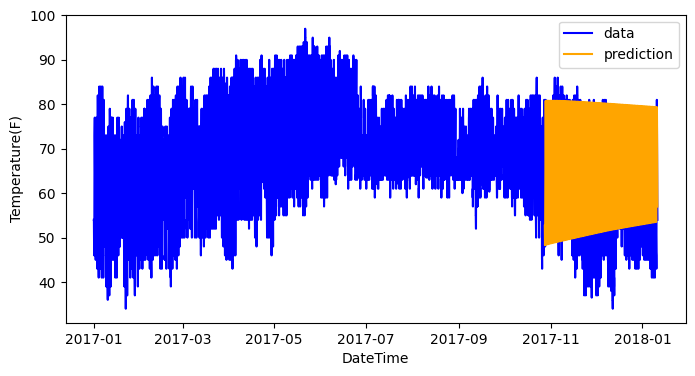

In [75]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df,x="DateTime",y="Temperature(F)",color="blue",label="data")
sns.lineplot(data=prediction,x="DateTime",y="Temperature(F)",color="orange",label="prediction")
plt.show()

In [76]:
mae = mean_absolute_error(test, y_pred)
rmse = mean_squared_error(test, y_pred, square_root=True)
mape = mean_absolute_percentage_error(test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 5.517701799365757
RMSE: 7.034041266514283
MAPE: 0.10357458927106232


* Fourier Trend

In [77]:
df_fourier = df.copy()

In [80]:
t= np.arange(len(df_fourier))
for order in range(1,10):
    df_fourier[f"fourier_sin_order_{order}"] = np.sin(2* np.pi * order * t*10)
    df_fourier[f"fourier_cos_order_{order}"] = np.cos(2* np.pi * order * t*10)
    
fourier_features = [i for i in list(df_fourier) if i.startswith("fourier")]
train_df_fourier = df_fourier[:-int(0.2*len(df))]
test_df_fourier = df_fourier[-int(0.2*len(df)):]

In [82]:
model = pm.auto_arima(
    train_df_fourier["Temperature(F)"],
    X = train_df_fourier[fourier_features],
    seasonal = False,
    stepwise = True,
    suppress_warnings = True,
    max_order = None,
    information_criterion = "aicc",
    error_action = "ignore"
)
y_pred = model.predict(n_periods = len(test_df_fourier), X=test_df_fourier[fourier_features])

In [84]:
prediction = pd.DataFrame({"Temperature(F)":y_pred})
prediction["DateTime"] = test_df["DateTime"]

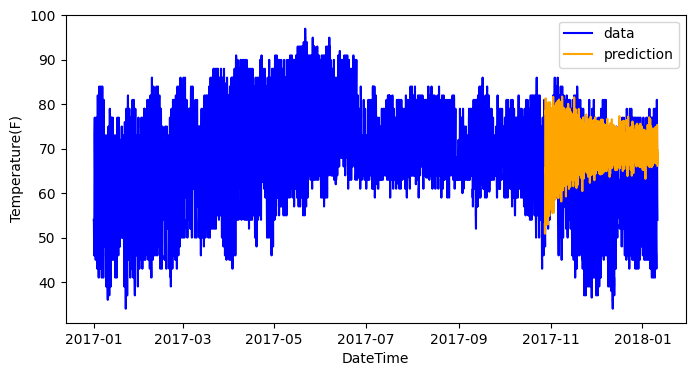

In [85]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df_fourier,x="DateTime",y="Temperature(F)",color="blue",label="data")
sns.lineplot(data=prediction,x="DateTime",y="Temperature(F)",color="orange",label="prediction")
plt.show()

In [86]:
mae = mean_absolute_error(test, y_pred)
rmse = mean_squared_error(test, y_pred, square_root=True)
mape = mean_absolute_percentage_error(test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 10.923453793519212
RMSE: 13.837551282882835
MAPE: 0.21417289509256834


* Seasonal Differencing

In [89]:
df_diff = df.copy()
df_diff["Temperature(F)"] = df["Temperature(F)"].diff(7201)
df_diff["DateTime"] = df["DateTime"]

train_diff = df["Temperature(F)"][:-int(0.2*len(df))]
test_diff = df["Temperature(F)"][-int(0.2*len(df)):]

train_diff.dropna(inplace=True)
base = df.iloc[int(-len(df)*0.2)-7201].loc["Temperature(F)"]

In [90]:
train_diff = df_diff["Temperature(F)"]

In [91]:
model_arima = ARIMA(train_diff,order=(20,0,20))
model_arima = model_arima.fit()
y_pred_diff = model_arima.forecast(len(test))

/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [92]:
y_pred_diff = list(y_pred_diff)

In [94]:
y_pred = []
for i in range(len(test)):
    if i<7201:
        value = df.iloc[int(-len(df)*0.2)-7201+i].loc["Temperature(F)"]
        y_pred.append(y_pred_diff[i]+value)
    else:
        y_pred.append(y_pred_diff[i]+y_pred[-1])

In [95]:
prediction = pd.DataFrame({"Temperature(F)":y_pred})
prediction.index = range(7201,7201+len(test))
prediction["DateTime"] = test_df["DateTime"]


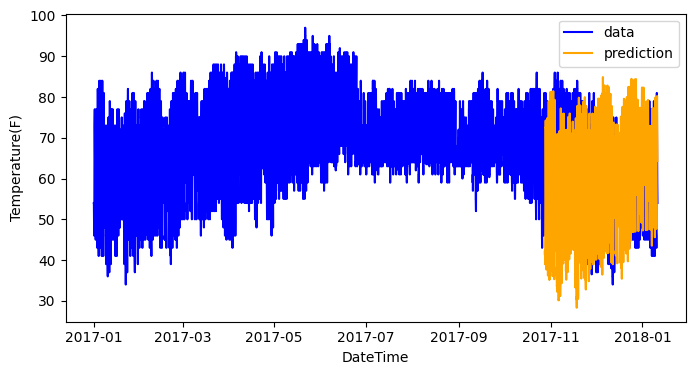

In [96]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df,x="DateTime",y="Temperature(F)",color="blue",label="data")
sns.lineplot(data=prediction,x="DateTime",y="Temperature(F)",color="orange",label="prediction")
plt.show()

In [97]:
mae = mean_absolute_error(test, y_pred)
rmse = mean_squared_error(test, y_pred, square_root=True)
mape = mean_absolute_percentage_error(test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 7.972406961451157
RMSE: 9.996441825855326
MAPE: 0.13701272652648197
